In [1]:
from rasterstats import zonal_stats
import rasterio
import pandas as pd
import xarray as xr
import geopandas as gpd
import odc.geo.xr
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rioxarray
from shapely.geometry import mapping

from dask.distributed import Client

In [40]:
VRE = "wind"


# just use daily data
def preprocess(ds):
    return (
    ds
    .sortby("time")
    .resample(time="1D")
    .mean()
    )

# open capacity factor data
root_path = Path(f'data/raw/{VRE}_cf')
files = sorted([
    f for f in root_path.glob("*.nc")
    if any(str(y) in f.name for y in range(2015, 2021))
])
# ds =  xr.open_mfdataset(
#         files,
#         preprocess=preprocess,
#         concat_dim='time',
#         combine='nested',
#         data_vars='minimal',
#         coords='minimal',
#         compat='override',
#         parallel=True,
#         chunks='auto'
#     )

In [41]:
files

[PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2015_Aus.nc'),
 PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2016_Aus.nc'),
 PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2017_Aus.nc'),
 PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2018_Aus.nc'),
 PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2019_Aus.nc'),
 PosixPath('data/raw/wind_cf/wind_capacity_factor_van_der_Wiel_era5_hourly_2020_Aus.nc')]

In [ ]:
# set up dask
client = Client(
    n_workers=24,
    threads_per_worker=1
)
client

In [20]:
def preprocess(ds):
    return (
    ds
    .sortby("time")
    .resample(time="1D")
    .mean()
    )

In [30]:
# open capacity factor data
root_path = Path('data/raw/solar_cf')

files = sorted([
    f for f in root_path.glob("*.nc")
    if any(str(y) in f.name for y in range(1979, 2021))
])

ds =  xr.open_mfdataset(
        files,
        preprocess=preprocess,
        concat_dim='time',
        combine='nested',
        data_vars='minimal',
        coords='minimal',
        compat='override',
        parallel=True,
        chunks='auto'
    )

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/pyth

In [6]:
# set up geo metadata so it can work with the shape file
daily_cf = (
    daily_cf
    .rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    .rio.write_crs("EPSG:4326")
)

In [7]:
# load the shape file with REZ boundaries
shapefile = 'data/raw/shapefiles/REZ-boundaries.shx'
gdf_rez = gpd.read_file(shapefile)

In [15]:
# list to store state based data
state_data = []

# states we are interested in
states = [
    'Q',
    'N',
    'V',
    'S',
    'T',
]

# Loop over the states and compute mean capacity factor in the REZs
for state in states:

    # get the REZs for the state
    gdf_state = gdf_rez[gdf_rez["Name"].str.startswith(state, na=False)]

    # get the CF data in the state's REZs
    sol_state = CF_solar.rio.clip(
        gdf_state.geometry.apply(mapping),  # Convert to GeoJSON format
        gdf_state.crs,
        drop=True  # Drops data outside polygons
    )

    # take the spatial mean to convert to a timeseries
    sol_state_mean = sol_state.mean(['lon', 'lat'])
    # name the data based on the state
    sol_state_mean = sol_state_mean.rename(state)
    # add the the list
    state_data.append(sol_state_mean)

# combine states into single dataset
CF_states = xr.merge(state_data)

/jobfs/171417077.gadi-pbs/ipykernel_3846692/1188437275.py:34: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  CF_states = xr.merge(state_data)


In [16]:
CF_states.compute()

<xarray.Dataset> Size: 10kB
Dimensions:      (time: 365)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    spatial_ref  int64 8B 0
Data variables:
    Q            (time) float32 1kB 0.2043 0.2203 0.2257 ... 0.2593 0.2357
    N            (time) float32 1kB 0.271 0.2758 0.2953 ... 0.2528 0.3102 0.2761
    V            (time) float32 1kB 0.2914 0.2764 0.2513 ... 0.2652 0.3406
    S            (time) float32 1kB 0.3077 0.3226 0.3168 ... 0.3136 0.3349
    T            (time) float32 1kB 0.2877 0.2826 0.1799 ... 0.2821 0.3271

In [ ]:
save_path = Path('data/processed/daily-state-cf')
os.makedirs(save_path, exist_ok=True)

In [17]:
CF_states

<xarray.Dataset> Size: 10kB
Dimensions:      (time: 365)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    spatial_ref  int64 8B 0
Data variables:
    Q            (time) float32 1kB dask.array<chunksize=(197,), meta=np.ndarray>
    N            (time) float32 1kB dask.array<chunksize=(197,), meta=np.ndarray>
    V            (time) float32 1kB dask.array<chunksize=(197,), meta=np.ndarray>
    S            (time) float32 1kB dask.array<chunksize=(197,), meta=np.ndarray>
    T            (time) float32 1kB dask.array<chunksize=(197,), meta=np.ndarray>

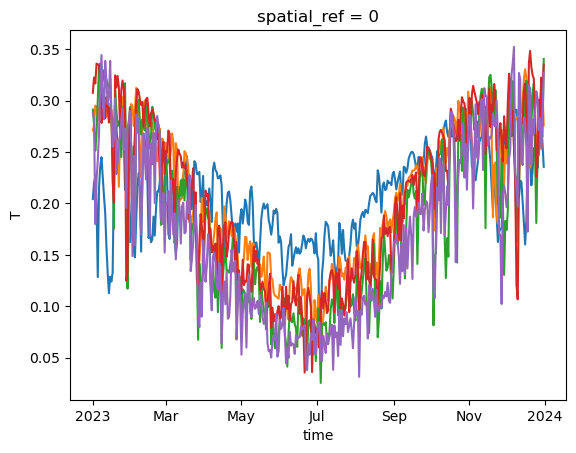

In [18]:
for state in states:
    CF_states[state].plot()